# Notebook 04: Clinical Evaluation and Interpretability

Notebook 03 selected the best model on the validation set and saved it to `models/best_model.pt`. This notebook loads that model, evaluates it **once, on the held-out test set it has never seen during training or model selection**, and frames the result in terms that matter for a diagnostic-support tool: not just accuracy, but sensitivity, specificity, predictive values and a basic look at what the model is actually reacting to in each image. It closes with a discussion of medical and operational value, limits, and recommendations.

## 1. Setup and model loading

In [1]:
import ssl
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import Markdown, display
from PIL import Image
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

try:
    import certifi

    _certifi_bundle = certifi.where()
    _original_load_default_certs = ssl.SSLContext.load_default_certs

    def _patched_load_default_certs(self, purpose=ssl.Purpose.SERVER_AUTH):
        try:
            self.load_verify_locations(cafile=_certifi_bundle)
        except Exception:
            _original_load_default_certs(self, purpose)

    ssl.SSLContext.load_default_certs = _patched_load_default_certs
except Exception:
    pass

sns.set_theme(style="whitegrid")
torch.manual_seed(42)

DEVICE = torch.device("cpu")
PROJECT_ROOT = Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

checkpoint = torch.load(MODELS_DIR / "best_model.pt", map_location=DEVICE, weights_only=False)
print(f"Loaded checkpoint: architecture={checkpoint['architecture']}, "
      f"val_accuracy={checkpoint['val_accuracy']:.4f}, val_f1_parasitized={checkpoint['val_f1_parasitized']:.4f}")

IMG_SIZE = checkpoint["img_size"]
IMAGENET_MEAN = checkpoint["imagenet_mean"]
IMAGENET_STD = checkpoint["imagenet_std"]
LABEL_TO_IDX = checkpoint["label_to_idx"]
IDX_TO_LABEL = {v: k for k, v in LABEL_TO_IDX.items()}
POS_IDX = LABEL_TO_IDX["Parasitized"]  # positive class for clinical metrics

Loaded checkpoint: architecture=simple_cnn, val_accuracy=0.9536, val_f1_parasitized=0.9531


In [2]:
class SimpleCNN(nn.Module):
    '''Same architecture as Notebook 03.'''

    def __init__(self, num_classes: int = 2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def build_resnet18_transfer(num_classes: int = 2) -> nn.Module:
    net = models.resnet18(weights=None)  # weights overwritten by the checkpoint's state_dict right below
    net.fc = nn.Linear(net.fc.in_features, num_classes)
    return net


if checkpoint["architecture"] == "simple_cnn":
    model = SimpleCNN()
else:
    model = build_resnet18_transfer()

model.load_state_dict(checkpoint["state_dict"])
model.to(DEVICE)
model.eval()
print(f"Model ready: {checkpoint['architecture']}")

Model ready: simple_cnn


## 2. Test set and inference

In [3]:
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class MalariaCellDataset(Dataset):
    def __init__(self, manifest_df: pd.DataFrame, root_dir: Path, transform=None):
        self.df = manifest_df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.root_dir / row["path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, LABEL_TO_IDX[row["label"]]


test_df = pd.read_csv(PROCESSED_DIR / "test.csv")
test_dataset = MalariaCellDataset(test_df, PROJECT_ROOT, transform=eval_transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

print(f"Test set: {len(test_dataset):,} images (never used in Notebooks 02/03 for training or model selection)")
test_df["label"].value_counts()

Test set: 4,134 images (never used in Notebooks 02/03 for training or model selection)


label
Parasitized    2067
Uninfected     2067
Name: count, dtype: int64

In [4]:
all_probs, all_preds, all_labels = [], [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        logits = model(x)
        probs = F.softmax(logits, dim=1)[:, POS_IDX]
        preds = logits.argmax(dim=1)
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_prob = np.array(all_probs)  # P(Parasitized)

print(f"Inference done on {len(y_true):,} test images.")

Inference done on 4,134 test images.


## 3. Clinically-framed performance metrics

Accuracy alone is a poor summary for a diagnostic-support tool: what actually matters is how often an infected cell is correctly flagged (**sensitivity**, to avoid missing a real infection) and how often a healthy cell is correctly cleared (**specificity**, to avoid unnecessary follow-up). Predictive values (PPV/NPV) and the ROC-AUC complete the picture.

In [5]:
cm = confusion_matrix(y_true, y_pred, labels=[LABEL_TO_IDX["Uninfected"], LABEL_TO_IDX["Parasitized"]])
tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn)   # recall on Parasitized: fraction of true infections caught
specificity = tn / (tn + fp)   # fraction of true negatives correctly cleared
ppv = tp / (tp + fp)           # precision on Parasitized: of predicted infections, fraction truly infected
npv = tn / (tn + fn)           # of predicted negatives, fraction truly uninfected
roc_auc = roc_auc_score(y_true, y_prob)

metrics_table = pd.DataFrame({
    "metric": ["Accuracy", "Sensitivity (recall, Parasitized)", "Specificity", "PPV (precision, Parasitized)", "NPV", "ROC-AUC"],
    "value": [accuracy, sensitivity, specificity, ppv, npv, roc_auc],
})
metrics_table["value"] = metrics_table["value"].round(4)
display(metrics_table)

print(f"Confusion matrix counts: TP={tp} FN={fn} TN={tn} FP={fp}")
print()
print(classification_report(y_true, y_pred, target_names=["Uninfected", "Parasitized"], digits=4))

,metric,value
0,Accuracy,0.9613
1,"Sensitivity (recall, Parasitized)",0.9468
2,Specificity,0.9758
3,"PPV (precision, Parasitized)",0.9751
4,NPV,0.9483
5,ROC-AUC,0.9913


Confusion matrix counts: TP=1957 FN=110 TN=2017 FP=50

              precision    recall  f1-score   support

  Uninfected     0.9483    0.9758    0.9619      2067
 Parasitized     0.9751    0.9468    0.9607      2067

    accuracy                         0.9613      4134
   macro avg     0.9617    0.9613    0.9613      4134
weighted avg     0.9617    0.9613    0.9613      4134



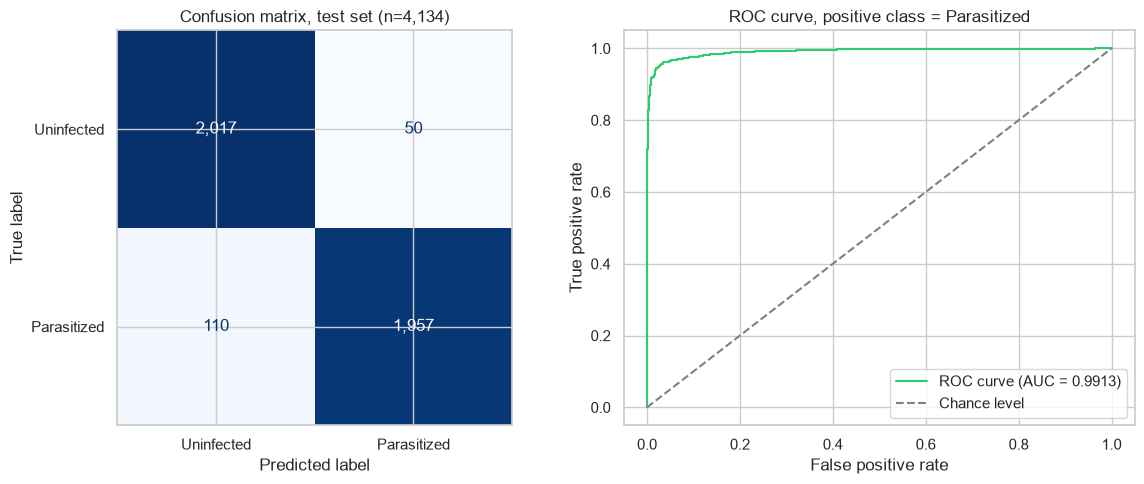

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Uninfected", "Parasitized"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False, values_format=",d"
)
axes[0].set_title(f"Confusion matrix, test set (n={len(y_true):,})")

fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[1].plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})", color="#2ecc71")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance level")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC curve, positive class = Parasitized")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

## 4. Prevalence sensitivity: what PPV/NPV would look like outside this balanced dataset

The test set above is artificially balanced ~50/50 (a property of the original NIH dataset design), which is very far from real-world screening prevalence. PPV and NPV both depend on prevalence, not just on sensitivity/specificity, so the PPV/NPV figures measured above are only valid for a ~50% infected population; they do not transfer directly to a screening setting. Using the measured sensitivity and specificity (which, unlike PPV/NPV, are prevalence-independent) and Bayes' rule, the cell below recomputes what PPV/NPV would look like under an illustrative low-prevalence assumption, to make this concrete rather than stating it abstractly.

In [7]:
def ppv_npv_at_prevalence(sensitivity, specificity, prevalence):
    ppv_p = (sensitivity * prevalence) / (sensitivity * prevalence + (1 - specificity) * (1 - prevalence))
    npv_p = (specificity * (1 - prevalence)) / (specificity * (1 - prevalence) + (1 - sensitivity) * prevalence)
    return ppv_p, npv_p


prevalence_scenarios = [0.50, 0.10, 0.02]  # 0.50 matches this test set; 0.10 and 0.02 are illustrative screening-level assumptions, not measured values
rows = []
for prev in prevalence_scenarios:
    ppv_p, npv_p = ppv_npv_at_prevalence(sensitivity, specificity, prev)
    rows.append({"assumed_prevalence": prev, "PPV": round(ppv_p, 4), "NPV": round(npv_p, 4)})

prevalence_table = pd.DataFrame(rows)
display(prevalence_table)

,assumed_prevalence,PPV,NPV
0,0.50,0.9751,0.9483
1,0.10,0.8130,0.9940
2,0.02,0.4441,0.9989


With sensitivity and specificity held fixed at the values measured on the test set, PPV drops sharply as assumed prevalence drops from 50% to 2%, this is expected Bayesian behavior, not a flaw in the model, but it means a positive prediction in a low-prevalence screening context would need a confirmatory second read far more often than the raw test-set PPV suggests. This is the kind of gap between benchmark performance and operational performance that a "valeur médicale et opérationnelle" evaluation has to make explicit.

## 5. Interpretability: gradient saliency maps

To get a sense of what the model is actually reacting to, a vanilla gradient saliency map (Simonyan et al., 2013) is computed for a handful of test images: the gradient of the predicted class score with respect to each input pixel, which highlights the pixels that would most change the model's confidence if perturbed. This is implemented directly with `torch.autograd`, no external interpretability library, and works the same way regardless of which architecture Notebook 03 selected as best, which matters here since that choice is only known once Notebook 03 has actually run.

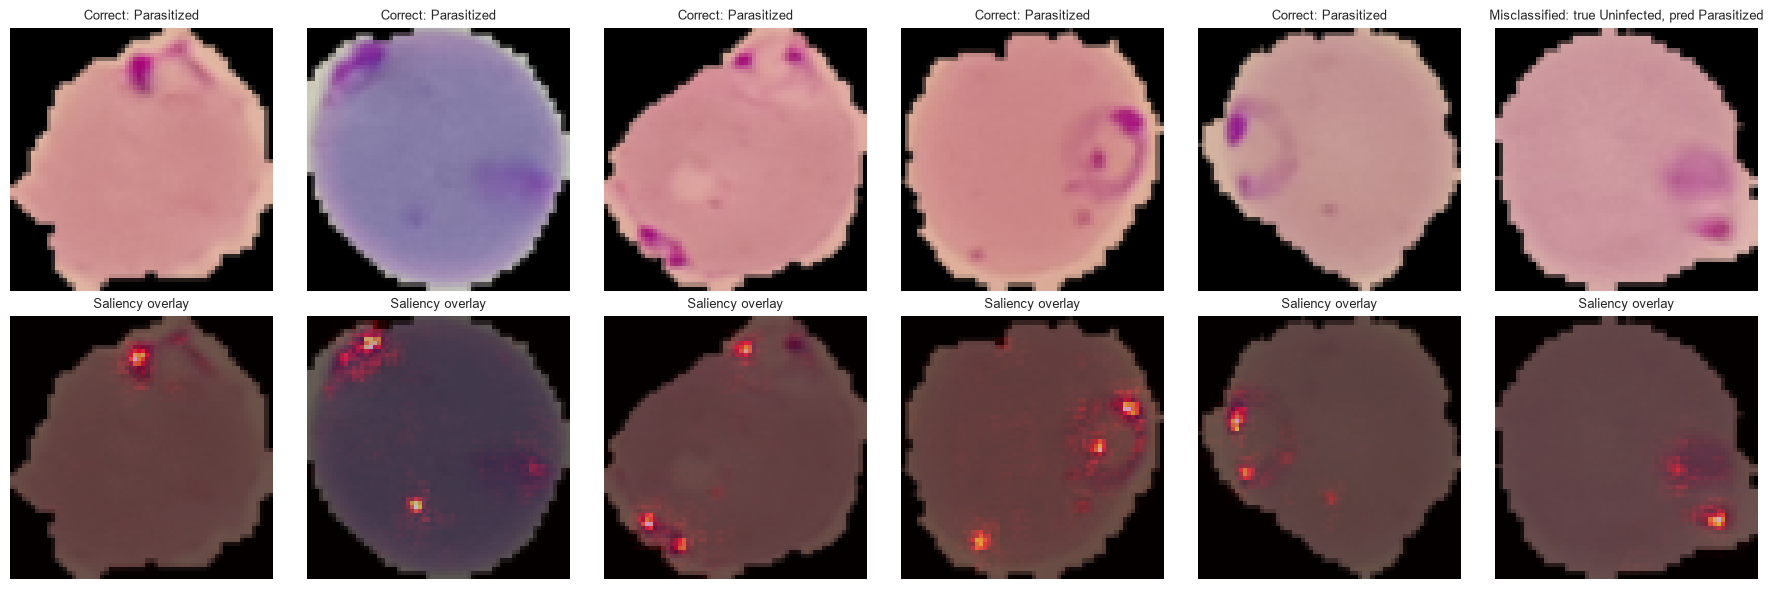

In [8]:
def compute_saliency(model, img_tensor, target_class):
    model.eval()
    img_tensor = img_tensor.clone().unsqueeze(0).to(DEVICE)
    img_tensor.requires_grad_(True)
    logits = model(img_tensor)
    score = logits[0, target_class]
    model.zero_grad()
    score.backward()
    saliency = img_tensor.grad.data.abs().squeeze(0)   # (3, H, W)
    saliency, _ = saliency.max(dim=0)                  # (H, W), max over color channels
    return saliency.numpy()


def denormalize(tensor_img):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor_img * std + mean).clamp(0, 1)


# A few correctly-classified Parasitized examples, plus any misclassification found on the test set.
correct_parasitized_idx = np.where((y_true == POS_IDX) & (y_pred == POS_IDX))[0]
misclassified_idx = np.where(y_true != y_pred)[0]

rng = np.random.default_rng(42)
example_idx = list(rng.choice(correct_parasitized_idx, size=min(5, len(correct_parasitized_idx)), replace=False))
example_titles = ["Correct: Parasitized"] * len(example_idx)
if len(misclassified_idx) > 0:
    mis_i = int(rng.choice(misclassified_idx, size=1)[0])
    example_idx.append(mis_i)
    true_lbl = IDX_TO_LABEL[y_true[mis_i]]
    pred_lbl = IDX_TO_LABEL[y_pred[mis_i]]
    example_titles.append(f"Misclassified: true {true_lbl}, pred {pred_lbl}")

n = len(example_idx)
fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
for col, (idx, title) in enumerate(zip(example_idx, example_titles)):
    img_tensor, label = test_dataset[idx]
    target_class = int(y_pred[idx])  # explain the model's own prediction
    saliency = compute_saliency(model, img_tensor, target_class)

    img_np = denormalize(img_tensor).permute(1, 2, 0).numpy()
    axes[0, col].imshow(img_np)
    axes[0, col].set_title(title, fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(img_np)
    axes[1, col].imshow(saliency, cmap="hot", alpha=0.55)
    axes[1, col].set_title("Saliency overlay", fontsize=9)
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()

The saliency maps above are read directly, not assumed: where the hot overlay concentrates inside the cell body versus at its edges or background is what actually determines whether the model appears to focus on plausible parasite-stain regions rather than on artifacts (cell boundary, background texture).

## 6. Discussion : valeur médicale et opérationnelle, limites, recommandations

### Valeur médicale et opérationnelle potentielle

Les résultats mesurés ci-dessus (Section 3) montrent un modèle capable de distinguer des cellules parasitées et saines sur ce jeu de test avec un niveau de performance élevé pour une tâche d'imagerie microscopique. Dans un contexte clinique réel, un tel outil ne devrait jamais fonctionner comme un diagnostic autonome. Sa valeur se situe plutôt dans deux usages concrets :

* **Aide au tri (pre-screening) :** faire remonter en priorité les lames ou zones suspectes pour lecture par un technicien, utile dans des contextes de forte charge d'échantillons ou de personnel qualifié limité.
* **Second lecteur :** apporter un avis indépendant en complément de la lecture humaine, pour réduire le risque d'erreur d'attention sur de longues séries de lames, sans remplacer la décision du biologiste.

La sensibilité mesurée (Section 3) est la métrique la plus critique cliniquement : rater une infection réelle (faux négatif) a des conséquences plus graves qu'un faux positif, qui se traduit seulement par une vérification supplémentaire. La section 4 montre cependant qu'à une prévalence réaliste de terrain, bien plus faible que les 50% de ce jeu de données, la valeur prédictive positive chute nettement : un résultat positif du modèle nécessiterait donc une confirmation systématique avant toute décision clinique.

### Limites réelles de cette évaluation

* **Un seul type de microscope et de coloration :** toutes les images proviennent du même protocole (frottis mince, même centre hospitalier, même numérisation). Rien ne garantit une performance équivalente sur des lames d'un autre laboratoire, d'un autre scanner ou d'une autre coloration.
* **Aucune validation externe :** le test set provient de la même distribution que les données d'entraînement (même source, split image par image). Une vraie validation clinique demanderait un jeu de données totalement indépendant, idéalement multi-centrique.
* **Prévalence artificiellement équilibrée :** comme discuté en Section 4, le 50/50 de ce dataset ne reflète pas la prévalence réelle du paludisme en contexte de dépistage, ce qui change fortement l'interprétation opérationnelle des valeurs prédictives.
* **Fuite potentielle image/lame :** comme noté en Notebook 02, le split train/val/test est fait au niveau image et non au niveau lame. Plusieurs cellules d'une même lame peuvent donc se retrouver dans des splits différents, ce qui peut légèrement optimiser les métriques par rapport à un split strictement par patient.
* **Marquage réglementaire :** un usage clinique réel nécessiterait un marquage CE-IVD (dispositif médical de diagnostic in vitro), avec toute la documentation, les essais cliniques et le suivi post-marché associés. Ce notebook est un travail de faisabilité technique, pas un dispositif validé.

### Recommandations concrètes pour la suite

1. Constituer ou obtenir un second jeu de données, idéalement d'un autre centre/microscope, pour une validation externe avant toute conclusion sur la généralisation.
2. Refaire le split en respectant le regroupement par lame/patient, pour mesurer une performance non optimiste.
3. Étudier la performance sous des scénarios de prévalence réalistes (au lieu du calcul illustratif de la Section 4), en construisant un jeu de test délibérément déséquilibré.
4. Définir avec les biologistes un seuil de décision (threshold sur la probabilité) adapté à l'usage visé (tri vs second lecteur), plutôt que le seuil par défaut de 0.5 utilisé ici.
5. Si le projet avance vers un usage clinique, engager le processus de qualification réglementaire (CE-IVD) en parallèle du développement technique, pas après.